# GSW Yield Curve — Data Preparation

Loads raw data, processes it, extracts Nelson-Siegel and PCA macro factors,
constructs the FAVAR state vector, and saves everything to `../data/processed/`.

**Run this notebook before the modelling notebook.**

## Output manifest

| File | Contents |
|------|----------|
| `yields_monthly.csv` | Monthly GSW yields (pre-alignment) |
| `yields_aligned.csv` | 11-tenor yields on common index |
| `macro_aligned.csv` | ~25-col processed macro panel |
| `ssr_monthly.csv` | Krippner (2015) shadow short rate |
| `ns_factors.csv` | NS level, slope, curvature, lambda |
| `pca_factors.csv` | 3 PCA macro factors (full panel) |
| `pca_factors_exp.csv` | 4 PCA macro factors (expanded panel) |
| `pca_key4_factors.csv` | 2 PCA factors from KEY4 panel |
| `favar_data.csv` | NS factors + pca_factors combined |
| `favar_diff.csv` | First-differenced favar_data |
| `pca_model_3f.npz` | 3F PCA arrays for reconstruction |
| `pca_scaler_3f.npz` | 3F StandardScaler arrays |
| `pca_model_key4.npz` | KEY4 PCA arrays |
| `pca_scaler_key4.npz` | KEY4 scaler arrays |
| `config.json` | Constants (dates, maturities, tenor labels, variance ratios) |
| `selected_macro_vars.json` | Macro variables passing 90% coverage filter |

## 0. Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

os.makedirs('../data/processed', exist_ok=True)
print('Setup complete. Output directory: ../data/processed/')

Setup complete. Output directory: ../data/processed/


In [2]:
# Define data parameters
START_DATE = '1985-01-01'  # GSW notebook: analysis from 1985
END_DATE = '2025-12-31'
# Zero Lower Bound threshold — FF rate <= this is treated as ZLB
ZLB_THRESHOLD = 0.25  # %


# Extended Yield curve maturities (in months) for Nelson-Siegel
# Covers full curve from 1M to 30Y
MATURITIES = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]  # In years

# readable tenor labels (used for tables/plots)
TENOR_LABELS = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
# NOTE: No YIELD_TICKER_TO_TENOR needed — GSW CSV already uses TENOR_LABELS as column names

# Extended macro data tickers for yield curve prediction
MACRO_TICKERS = {
    'inflation': 'CPIAUCSL',           # CPI - inflation baseline
    'inflation_ex': 'CPILFESL',        # Core CPI - inflation excluding food and energy
    'output': 'INDPRO',                # Industrial Production
    'fedfunds': 'FEDFUNDS',            # Federal Funds Rate
    'fedfunds_eff': 'DFF',             # Effective Fed Funds Rate (daily)
    'unemployment': 'UNRATE',          # Unemployment Rate
    'payroll': 'PAYEMS',               # Nonfarm Payroll
    'retail_sales': 'RSXFS',           # Retail Sales ex auto and gas
    'housing': 'HOUST',                # Housing Starts
    'equity_market': 'SP500',          # S&P 500 Index
    'volatility': 'VIXCLS',            # VIX (Volatility Index)
    'hy_spread': 'BAMLH0A0HYM2',       # HY OAS spread (credit spreads)
    'credit_spread': 'BAMLH0A2HYC2',   # HY Option-Adjusted Spread
    'money_supply': 'M2SL',            # M2 Money Supply
    '5y_breakeven_inflation': 'T5YIE', # 5-Year Breakeven Inflation Rate
    'mortgage_rate': 'MORTGAGE30US',   # 30-year Mortgage Rate
}

print(f"Data period: {START_DATE} to {END_DATE}")
print(f"GSW yield tenors ({len(TENOR_LABELS)}): {TENOR_LABELS}")
print(f"Extended macro tickers ({len(MACRO_TICKERS)} series): {list(MACRO_TICKERS.keys())}")

Data period: 1985-01-01 to 2025-12-31
GSW yield tenors (11): ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
Extended macro tickers (16 series): ['inflation', 'inflation_ex', 'output', 'fedfunds', 'fedfunds_eff', 'unemployment', 'payroll', 'retail_sales', 'housing', 'equity_market', 'volatility', 'hy_spread', 'credit_spread', 'money_supply', '5y_breakeven_inflation', 'mortgage_rate']


## 1. Raw Data Loading

In [3]:
print("Loading GSW zero-coupon yield data (1M-30Y)...")
yields_raw = pd.read_csv('../data/yields_gsw_monthly.csv', index_col=0, parse_dates=True)
assert list(yields_raw.columns) == TENOR_LABELS, (
    f'GSW column mismatch: expected {TENOR_LABELS}, '
    f'got {list(yields_raw.columns)}'
)
yields_raw = yields_raw.sort_index()

print("Loading extended macroeconomic data...")
macro_raw = pd.read_csv('../data/macro_raw.csv', index_col=0, parse_dates=False)
valid_dates = pd.to_datetime(macro_raw.index, errors='coerce')
macro_raw = macro_raw[valid_dates.notna()]
macro_raw.index = pd.to_datetime(macro_raw.index)
macro_raw = macro_raw.apply(pd.to_numeric, errors='coerce')
macro_raw = macro_raw.sort_index()

# Restrict to analysis window (keeps notebook consistent with START_DATE/END_DATE)
_start = pd.to_datetime(START_DATE)
_end = pd.to_datetime(END_DATE)
yields_raw = yields_raw.loc[_start:_end]
macro_raw = macro_raw.loc[_start:_end]

print(f"GSW yield data shape: {yields_raw.shape}")
print(f"Yield columns: {list(yields_raw.columns)}")
print(f"Yield date range: {yields_raw.index.min().date()} – {yields_raw.index.max().date()}\n")

print(f"Macro data shape: {macro_raw.shape}")
print(f"Macro tickers loaded: {list(macro_raw.columns)}")
print(f"Macro date range: {macro_raw.index.min().date()} – {macro_raw.index.max().date()}")

Loading GSW zero-coupon yield data (1M-30Y)...
Loading extended macroeconomic data...


GSW yield data shape: (492, 11)
Yield columns: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
Yield date range: 1985-01-31 – 2025-12-31

Macro data shape: (14975, 35)
Macro tickers loaded: ['CPIAUCSL', 'CPILFESL', 'PCECTPI', 'PCEPILFE', 'PPIACO', 'PPIFGS', 'DCOILWTICO', 'T5YIE', 'MICH', 'FEDFUNDS', 'DFF', 'UNRATE', 'PAYEMS', 'UEMPMEAN', 'LNS14000025', 'ICSA', 'AWHNONAG', 'INDPRO', 'CUMFNS', 'DGORDER', 'RSXFS', 'HOUST', 'PERMIT', 'UMCSENT', 'M1SL', 'M2SL', 'BOGMBASE', 'SP500', 'VIXCLS', 'BAMLH0A0HYM2', 'BAA10YM', 'T10Y2Y', 'T10Y3M', 'MORTGAGE30US', 'DTWEXBGS']
Macro date range: 1985-01-01 – 2025-12-31


In [4]:
# =============================================================================
# SHADOW SHORT RATE (SSR) — Krippner (2015/2021)
# Source: ljkmfa.com — SSR_Estimates_20260331.xlsx
# Replaces Fed Funds Rate during ZLB episodes to capture unconventional policy.
# =============================================================================
_ssr_raw = pd.read_excel(
    '../data/SSR_Estimates_20260331 (1).xlsx',
    sheet_name='D. Monthly average SSR series',
    header=None, skiprows=20
)
_ssr_raw.columns = [
    '_num', 'date', 'US_SSR', 'EA_SSR', 'JP_SSR', 'UK_SSR',
    'CH_SSR', 'CA_SSR', 'AU_SSR', 'NZ_SSR', 'SE_SSR', 'NO_SSR', 'DK_SSR'
]
_ssr_raw['date'] = pd.to_datetime(_ssr_raw['date'])
ssr_monthly = _ssr_raw.set_index('date')[['US_SSR']].dropna()
ssr_monthly.index = ssr_monthly.index.to_period('M').to_timestamp('M')
ssr_monthly = ssr_monthly.loc[START_DATE:END_DATE]
_zlb = ssr_monthly[ssr_monthly['US_SSR'] < ZLB_THRESHOLD]
print(f'Shadow Rate (SSR) loaded: {len(ssr_monthly)} monthly obs '
      f'({ssr_monthly.index[0].strftime("%Y-%m")} '
      f'to {ssr_monthly.index[-1].strftime("%Y-%m")})')
print(f'ZLB periods (SSR < {ZLB_THRESHOLD}%): {len(_zlb)} months '
      f'({_zlb.index[0].strftime("%Y-%m")} to {_zlb.index[-1].strftime("%Y-%m")})')
print(f'SSR range: {ssr_monthly["US_SSR"].min():.2f}% to {ssr_monthly["US_SSR"].max():.2f}%')


Shadow Rate (SSR) loaded: 372 monthly obs (1995-01 to 2025-12)
ZLB periods (SSR < 0.25%): 115 months (2003-06 to 2021-12)
SSR range: -4.00% to 6.78%


In [5]:
print('Yield data (first 3 rows):')
display(yields_raw.head(3))
print(f'\nMacro data: {macro_raw.shape}, columns: {list(macro_raw.columns[:8])} ...')
print('\nSSR data (first 3 rows):')
display(ssr_monthly.head(3))

Yield data (first 3 rows):


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Date,,,,,,,,,,,
1985-01-31,7.769739,8.037114,8.399221,9.002834,9.846760,10.369220,10.909153,11.149825,11.332843,11.678911,11.897507
1985-02-28,8.368408,8.556636,8.820080,9.284588,10.002452,10.500342,11.058996,11.286613,11.393520,11.962177,13.180926
1985-03-31,8.893585,9.091075,9.362743,9.827713,10.508413,10.951148,11.420269,11.615023,11.735608,12.034250,12.330343



Macro data: (14975, 35), columns: ['CPIAUCSL', 'CPILFESL', 'PCECTPI', 'PCEPILFE', 'PPIACO', 'PPIFGS', 'DCOILWTICO', 'T5YIE'] ...

SSR data (first 3 rows):


,US_SSR
date,
1995-01-31,6.505078
1995-02-28,6.217974
1995-03-31,5.949699


## 2. Yield Processing & Alignment

In [6]:
def process_yields(yields_df):
    """
    Process GSW yield data: data is already monthly, only gap-fill needed.
    
    Parameters:
    -----------
    yields_df : pd.DataFrame
        Raw yield data
    
    Returns:
    --------
    pd.DataFrame
        Processed monthly yield data
    """
    if not isinstance(yields_df.index, pd.DatetimeIndex):
        yields_df.index = pd.to_datetime(yields_df.index)
        
    # GSW data is already monthly — copy and gap-fill only
    yields_monthly = yields_df.copy()  # GSW: already monthly
    
    # Forward fill then backward fill small gaps
    yields_monthly = yields_monthly.ffill().bfill()

    
    return yields_monthly


def process_macro(macro_df):
    """
    Process macro data: resample to monthly, apply appropriate transformations.
    Level series: rates, spreads, indices, sentiment.
    Flow series: log-differenced and annualised (x1200 for monthly).
    """
    if not isinstance(macro_df.index, pd.DatetimeIndex):
        macro_df.index = pd.to_datetime(macro_df.index)
    macro_monthly = macro_df.resample("ME").mean()
    processed = pd.DataFrame(index=macro_monthly.index)

    # --- Price level series (log-diff, annualised) ---
    for col, name in [("CPIAUCSL", "inflation"), ("CPILFESL", "inflation_core"),
                      ("PCECTPI", "pce_inflation"), ("PCEPILFE", "pce_core"),
                      ("PPIACO", "ppi_all"), ("PPIFGS", "ppi_finished"),
                      ("DCOILWTICO", "oil_price")]:
        if col in macro_monthly.columns:
            processed[name] = np.log(macro_monthly[col]).diff() * 1200

    # --- Activity: output & employment (log-diff, annualised) ---
    for col, name in [("INDPRO", "output"), ("PAYEMS", "payroll"),
                      ("RSXFS", "retail_sales"), ("HOUST", "housing"),
                      ("CUMFNS", "capacity_util"), ("DGORDER", "durable_goods"),
                      ("PERMIT", "permits"), ("SP500", "equity_return"),
                      ("M2SL", "money_growth"), ("M1SL", "m1_growth"),
                      ("BOGMBASE", "monetary_base"), ("DTWEXBGS", "usd_index"),
                      ("ICSA", "init_claims")]:
        if col in macro_monthly.columns:
            processed[name] = np.log(macro_monthly[col]).diff() * 1200

    # --- Output gap proxy (real-time, one-sided) ---
    # Taylor rules are defined with an output GAP (deviation from potential), not output growth.
    # We proxy potential output with a trailing 10-year (120M) mean of log(INDPRO) to avoid look-ahead bias.
    if "INDPRO" in macro_monthly.columns:
        indpro_log = np.log(macro_monthly["INDPRO"]).replace([np.inf, -np.inf], np.nan)
        trend = indpro_log.rolling(window=120, min_periods=60).mean()
        processed["output_gap"] = (indpro_log - trend) * 100

    # --- Level series: rates, spreads, indices, sentiment ---
    for col, name in [("FEDFUNDS", "fedfunds"), ("DFF", "fedfunds_eff"),
                      ("UNRATE", "unrate"), ("UEMPMEAN", "unemp_duration"),
                      ("LNS14000025", "unrate_prime"), ("AWHNONAG", "avg_hours"),
                      ("T5YIE", "breakeven_inflation"),
                      ("MORTGAGE30US", "mortgage_rate"),
                      ("VIXCLS", "volatility"),
                      ("BAMLH0A0HYM2", "hy_spread"), ("BAMLH0A2HYC2", "credit_spread"),
                      ("BAA10YM", "baa_spread"),
                      ("T10Y2Y", "term_spread_10y2y"), ("T10Y3M", "term_spread_10y3m"),
                      ("MICH", "sentiment_mich"), ("UMCSENT", "sentiment_umcs")]:
        if col in macro_monthly.columns:
            processed[name] = macro_monthly[col]

    return processed


# Process data
yields_monthly = process_yields(yields_raw)
macro_processed = process_macro(macro_raw)

print("Processed yields shape:", yields_monthly.shape)
print("Processed yields columns:", list(yields_monthly.columns))
print("\nProcessed macro shape:", macro_processed.shape)
print("Processed macro columns:", list(macro_processed.columns))

Processed yields shape: (492, 11)
Processed yields columns: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

Processed macro shape: (492, 36)
Processed macro columns: ['inflation', 'inflation_core', 'pce_inflation', 'pce_core', 'ppi_all', 'ppi_finished', 'oil_price', 'output', 'payroll', 'retail_sales', 'housing', 'capacity_util', 'durable_goods', 'permits', 'equity_return', 'money_growth', 'm1_growth', 'monetary_base', 'usd_index', 'init_claims', 'output_gap', 'fedfunds', 'fedfunds_eff', 'unrate', 'unemp_duration', 'unrate_prime', 'avg_hours', 'breakeven_inflation', 'mortgage_rate', 'volatility', 'hy_spread', 'baa_spread', 'term_spread_10y2y', 'term_spread_10y3m', 'sentiment_mich', 'sentiment_umcs']


In [7]:
# Align datasets by common dates
common_index = yields_monthly.index.intersection(macro_processed.index)
yields_aligned = yields_monthly.loc[common_index]
macro_aligned = macro_processed.loc[common_index]

# Yields: enforce no missing values (we filled small gaps already)
yields_aligned = yields_aligned.dropna()

# Macro: keep missing values here; PCA step will select high-coverage variables
# and drop rows only for those selected variables.

# Final alignment (after yield dropping)
common_index = yields_aligned.index.intersection(macro_aligned.index)
yields_aligned = yields_aligned.loc[common_index]
macro_aligned = macro_aligned.loc[common_index]

print(f"Final aligned dataset:")
print(f"  Date range: {common_index[0].strftime('%Y-%m')} to {common_index[-1].strftime('%Y-%m')}")
print(f"  Number of observations: {len(common_index)}")
print(f"  Yields shape: {yields_aligned.shape}")
print(f"  Macro shape: {macro_aligned.shape}")
print(f"  Macro missingness (avg % missing): {macro_aligned.isna().mean().mean()*100:.2f}%")

Final aligned dataset:
  Date range: 1985-01 to 2025-12
  Number of observations: 492
  Yields shape: (492, 11)
  Macro shape: (492, 36)
  Macro missingness (avg % missing): 10.86%


In [8]:
# Summary statistics
print("="*70)
print("EXTENDED YIELD CURVE DATA (1M - 30Y)")
print("="*70)
print("\nYield Data Summary:")
display(yields_aligned.describe().round(2))

print("\n" + "="*70)
print("EXTENDED MACROECONOMIC DATA")
print("="*70)
print("\nMacro Data Summary (First 15 variables):")
macro_summary = macro_aligned.describe().round(2)
display(macro_summary.iloc[:, :min(15, len(macro_summary.columns))])

if len(macro_summary.columns) > 15:
    print(f"\n... and {len(macro_summary.columns) - 15} more variables")
    print(f"Total macro variables: {len(macro_summary.columns)}")

EXTENDED YIELD CURVE DATA (1M - 30Y)

Yield Data Summary:


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
count,492.00,492.00,492.00,492.00,492.00,492.00,492.00,492.00,492.00,492.00,492.00
mean,3.37,3.41,3.47,3.59,3.80,4.00,4.34,4.63,4.95,5.41,5.44
std,2.50,2.55,2.59,2.63,2.63,2.60,2.52,2.45,2.39,2.30,2.28
min,-0.06,0.02,0.07,0.07,0.12,0.17,0.30,0.44,0.63,1.15,1.43
25%,0.65,0.68,0.85,1.01,1.22,1.51,2.05,2.52,2.90,3.47,3.58
50%,3.44,3.56,3.57,3.71,3.95,4.06,4.14,4.31,4.56,5.06,4.96
75%,5.32,5.38,5.46,5.59,5.82,5.94,6.20,6.41,6.61,7.09,7.05
max,9.07,9.27,9.45,9.83,10.51,10.95,11.42,11.62,11.74,12.03,13.27



EXTENDED MACROECONOMIC DATA

Macro Data Summary (First 15 variables):


,inflation,inflation_core,pce_inflation,pce_core,ppi_all,ppi_finished,oil_price,output,payroll,retail_sales,housing,capacity_util,durable_goods,permits,equity_return
count,489.00,489.00,0.0,491.00,491.00,371.00,479.00,491.00,491.00,407.00,491.00,491.00,406.00,491.00,116.00
mean,2.76,2.77,NaN,2.34,2.27,1.97,2.32,1.52,1.21,4.41,-0.51,-0.13,3.05,-0.32,12.29
std,3.18,1.64,NaN,1.55,12.20,7.13,115.28,11.76,8.50,19.40,92.54,13.40,52.93,62.94,42.97
min,-21.44,-5.89,NaN,-6.84,-65.76,-36.90,-681.83,-169.71,-174.93,-153.87,-362.40,-197.29,-286.36,-328.85,-253.87
25%,1.43,1.80,NaN,1.33,-2.83,-1.18,-59.17,-2.52,0.56,-1.74,-53.24,-4.68,-20.35,-33.21,-2.71
50%,2.75,2.50,NaN,2.12,2.29,2.24,13.04,2.22,1.63,4.76,-2.53,0.53,4.18,-0.85,18.70
75%,4.29,3.68,NaN,3.09,8.10,5.87,67.25,6.30,2.54,11.13,57.27,4.51,32.23,34.70,36.99
max,16.41,9.69,NaN,8.42,37.94,22.64,655.02,76.17,41.06,201.38,257.95,90.68,280.79,247.69,94.81



... and 21 more variables
Total macro variables: 36


## 3. Nelson-Siegel Factor Extraction

Fit the Nelson-Siegel (1987) model cross-sectionally at each date:

$$y(\tau) = \beta_0 + \beta_1 \frac{1-e^{-\tau/\lambda}}{\tau/\lambda} + \beta_2\left(\frac{1-e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda}\right)$$

- **Level** ($\beta_0$): long-end rate
- **Slope** ($\beta_1$): short-end loading
- **Curvature** ($\beta_2$): medium-term hump
- **Lambda** ($\lambda$): decay speed (treated as random walk in forecasting)

In [9]:
def nelson_siegel(tau, beta0, beta1, beta2, lam):
    """
    Nelson-Siegel yield curve model.
    
    Parameters:
    -----------
    tau : float or array
        Maturity in years
    beta0 : float
        Level factor (long-term rate)
    beta1 : float
        Slope factor
    beta2 : float
        Curvature factor
    lam : float
        Decay parameter (lambda/tau)
    
    Returns:
    --------
    float or array
        Fitted yield(s)
    """
    tau = np.asarray(tau)
    
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        decay = tau / lam
        exp_decay = np.exp(-decay)
        
        # Loading for slope factor
        loading1 = np.where(decay != 0, (1 - exp_decay) / decay, 1.0)
        
        # Loading for curvature factor
        loading2 = loading1 - exp_decay
    
    return beta0 + beta1 * loading1 + beta2 * loading2


def fit_nelson_siegel(yields, maturities):
    """
    Fit Nelson-Siegel model to observed yields.
    
    Parameters:
    -----------
    yields : array
        Observed yields for different maturities
    maturities : array
        Corresponding maturities in years
    
    Returns:
    --------
    dict
        Fitted parameters (beta0, beta1, beta2, lambda)
    """
    maturities = np.array(maturities)
    yields = np.array(yields)
    
    def objective(params):
        beta0, beta1, beta2, lam = params
        fitted = nelson_siegel(maturities, beta0, beta1, beta2, lam)
        return np.sum((yields - fitted) ** 2)
    
    # Initial guesses based on yield curve characteristics
    # beta0: long rate, beta1: short - long, beta2: medium - average
    y_short = yields[0] if len(yields) > 0 else 2.0
    y_long = yields[-1] if len(yields) > 0 else 4.0
    
    initial_guess = [
        y_long,           # beta0 (level)
        y_short - y_long, # beta1 (slope)
        0.0,              # beta2 (curvature)
        1.5               # lambda (decay)
    ]
    
    # Bounds for optimization
    bounds = [
        (-10, 20),   # beta0
        (-15, 15),   # beta1
        (-15, 15),   # beta2
        (0.1, 10)    # lambda (must be positive)
    ]
    
    result = minimize(
        objective,
        initial_guess,
        method='L-BFGS-B',
        bounds=bounds
    )
    
    return {
        'beta0': result.x[0],
        'beta1': result.x[1],
        'beta2': result.x[2],
        'lambda': result.x[3],
        'success': result.success,
        'rmse': np.sqrt(result.fun / len(yields))
    }

In [10]:
def extract_ns_factors(yields_df, maturities):
    """
    Extract Nelson-Siegel factors for entire time series.

    Parameters:
    -----------
    yields_df : pd.DataFrame
        Yield data with dates as index
    maturities : list
        Maturities in years

    Returns:
    --------
    pd.DataFrame
        DataFrame with level, slope, curvature factors (and lambda, fit RMSE)
    """
    results = []

    for date in yields_df.index:
        yields = yields_df.loc[date].values

        # Skip if any yields are missing
        if np.any(np.isnan(yields)):
            results.append({
                'date': date,
                'level': np.nan,
                'slope': np.nan,
                'curvature': np.nan,
                'lambda': np.nan,
                'ns_fit_rmse': np.nan,
            })
            continue

        # Fit NS model
        params = fit_nelson_siegel(yields, maturities)

        results.append({
            'date': date,
            'level': params['beta0'],
            'slope': params['beta1'],
            'curvature': params['beta2'],
            'lambda': params['lambda'],
            'ns_fit_rmse': params['rmse'],
        })

    factors_df = pd.DataFrame(results).set_index('date')
    return factors_df


# Extract NS factors (this may take a minute)
print("Extracting Nelson-Siegel factors...")
ns_factors = extract_ns_factors(yields_aligned, MATURITIES)
print("Done!")

print(f"\nNelson-Siegel factors shape: {ns_factors.shape}")
display(ns_factors.head(10))

Extracting Nelson-Siegel factors...


Done!

Nelson-Siegel factors shape: (492, 5)


,level,slope,curvature,lambda,ns_fit_rmse
date,,,,,
1985-01-31,11.961597,-4.329877,-0.000058,1.232865,0.049321
1985-02-28,12.941236,-4.527540,-0.000005,2.517852,0.279899
1985-03-31,12.334690,-3.548543,-0.000008,1.348049,0.065035
1985-04-30,11.974779,-4.031470,-0.000005,1.307951,0.019250
1985-05-31,11.780389,-4.394547,-0.000031,1.714230,0.071043
1985-06-30,13.570413,-6.407350,-0.000013,5.208318,0.384434
1985-07-31,13.649094,-6.444247,0.000037,4.944031,0.385323
1985-08-31,13.054121,-5.832891,-0.000018,3.879711,0.321241
1985-09-30,12.707882,-5.539017,0.000155,3.307902,0.257794


Nelson-Siegel Factors Summary:


,level,slope,curvature,lambda,ns_fit_rmse
count,492.000,492.000,492.000,492.000,492.000
mean,5.786,-2.406,-2.012,2.367,0.064
std,2.190,1.822,2.628,1.608,0.050
min,1.998,-6.444,-7.544,0.111,0.000
25%,4.160,-3.839,-3.957,1.362,0.034
50%,5.526,-2.326,-1.823,1.844,0.055
75%,7.279,-1.068,-0.000,2.835,0.081
max,13.649,1.811,11.649,10.000,0.385


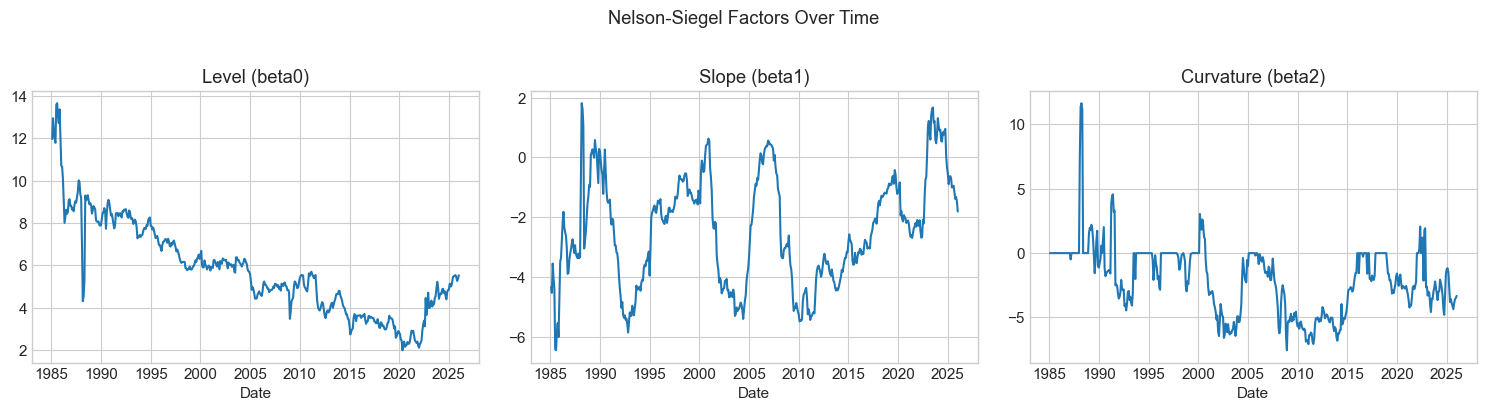

In [11]:
# Summary statistics for NS factors
print("Nelson-Siegel Factors Summary:")
display(ns_factors.describe().round(3))

# Plot NS factors over time
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                          ['level', 'slope', 'curvature'],
                          ['Level (beta0)', 'Slope (beta1)', 'Curvature (beta2)']):
    ax.plot(ns_factors.index, ns_factors[col])
    ax.set_title(title)
    ax.set_xlabel('Date')
plt.suptitle('Nelson-Siegel Factors Over Time', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/ns_factors_plot.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. PCA Macro Factors

Extracts principal components from the processed macro panel.

- **Coverage filter**: variables with >=90% non-missing observations
- **3-factor model**: used in NS-FAVAR
- **4-factor expanded**: FAVAR expanded-panel specification
- **KEY4 panel** (Caldeira et al. 2023): CPI inflation, Fed Funds, unemployment rate, industrial production index

In [12]:
def extract_pca_factors(macro_df, n_components=3):
    """
    Extract PCA factors from macro variables.
    Automatically selects variables with sufficient data coverage.
    
    Parameters:
    -----------
    macro_df : pd.DataFrame
        Processed macro data
    n_components : int
        Number of principal components to extract
    
    Returns:
    --------
    tuple
        (factors_df, pca_object, scaler_object, explained_variance_ratios, selected_variables)
    """
    # Select variables with good data coverage (>90% non-missing)
    data = macro_df.copy()
    coverage = 1 - (data.isna().sum() / len(data))
    
    # Use variables with >90% coverage
    selected_vars = coverage[coverage > 0.90].index.tolist()
    
    print(f"Variables selected for PCA ({len(selected_vars)}):")
    for var in selected_vars:
        print(f"  {var:25s}: {coverage[var]*100:.1f}% coverage")
    
    data_selected = data[selected_vars].copy()
    
    # Drop rows with any missing values
    data_selected = data_selected.dropna()
    
    # Standardize the data
    scaler = StandardScaler()
    data_standardized = scaler.fit_transform(data_selected)
    
    # Apply PCA
    pca = PCA(n_components=min(n_components, len(selected_vars)))
    factors = pca.fit_transform(data_standardized)
    
    # Create DataFrame with factors
    factor_names = [f'F{i+1}' for i in range(pca.n_components_)]
    factors_df = pd.DataFrame(
        factors,
        index=data_selected.index,
        columns=factor_names
    )
    
    return factors_df, pca, scaler, pca.explained_variance_ratio_, selected_vars


# Extract PCA factors (increased to 3 components with extended macro data)
pca_factors, pca_model, scaler, variance_ratios, selected_macro_vars = extract_pca_factors(
    macro_aligned, n_components=3
)

print("\n" + "="*60)
print("PCA Factors extracted successfully!")
print("="*60)
print(f"\nExplained Variance Ratios:")
for i, ratio in enumerate(variance_ratios):
    print(f"  F{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")
print(f"  Total: {sum(variance_ratios):.4f} ({sum(variance_ratios)*100:.2f}%)")

Variables selected for PCA (26):
  inflation                : 99.4% coverage
  inflation_core           : 99.4% coverage
  pce_core                 : 99.8% coverage
  ppi_all                  : 99.8% coverage
  oil_price                : 97.4% coverage
  output                   : 99.8% coverage
  payroll                  : 99.8% coverage
  housing                  : 99.8% coverage
  capacity_util            : 99.8% coverage
  permits                  : 99.8% coverage
  money_growth             : 99.8% coverage
  m1_growth                : 99.8% coverage
  monetary_base            : 99.8% coverage
  init_claims              : 99.8% coverage
  fedfunds                 : 100.0% coverage
  fedfunds_eff             : 100.0% coverage
  unrate                   : 99.8% coverage
  unemp_duration           : 99.8% coverage
  unrate_prime             : 99.8% coverage
  avg_hours                : 100.0% coverage
  mortgage_rate            : 100.0% coverage
  baa_spread               : 100.0% cov

In [13]:
# Show PCA loadings
factor_cols = [f'F{i+1}' for i in range(pca_model.n_components_)]
loadings = pd.DataFrame(
    pca_model.components_.T,
    columns=factor_cols,
    index=selected_macro_vars
)

print("\nPCA Factor Loadings:")
print("(Higher absolute values indicate stronger contributions to each factor)")
print("="*60)
display(loadings.round(4))


PCA Factor Loadings:
(Higher absolute values indicate stronger contributions to each factor)


,F1,F2,F3
inflation,0.1645,0.2207,0.0705
inflation_core,0.2248,0.1044,0.1484
pce_core,0.1943,0.1353,0.1573
ppi_all,0.0812,0.2604,0.0481
oil_price,0.0727,0.2747,0.0450
output,0.1191,0.3468,-0.0146
payroll,0.1334,0.3255,-0.0916
housing,0.0177,0.1872,-0.0477
capacity_util,0.0823,0.3816,-0.0130
permits,0.0024,0.1892,-0.0420


In [14]:
# Extract 4 macro factors from the expanded macro_aligned panel
N_MACRO_FACTORS_EXP = 4

pca_fac_exp, pca_obj_exp, scaler_exp, var_ratios_exp, sel_vars_exp = \
    extract_pca_factors(macro_aligned, n_components=N_MACRO_FACTORS_EXP)

print(f'Expanded macro panel: {macro_aligned.shape[1]} series available')
print(f'Series selected (coverage ≥ 90%): {len(sel_vars_exp)}')
print(f'\nPCA — {N_MACRO_FACTORS_EXP} components:')
for i, r in enumerate(var_ratios_exp, 1):
    print(f'  PC{i}: {r*100:.2f}%')
print(f'  Total explained: {sum(var_ratios_exp)*100:.2f}%')
print(f'  (Original 3-factor explained: {sum(variance_ratios)*100:.2f}%)')


Variables selected for PCA (26):
  inflation                : 99.4% coverage
  inflation_core           : 99.4% coverage
  pce_core                 : 99.8% coverage
  ppi_all                  : 99.8% coverage
  oil_price                : 97.4% coverage
  output                   : 99.8% coverage
  payroll                  : 99.8% coverage
  housing                  : 99.8% coverage
  capacity_util            : 99.8% coverage
  permits                  : 99.8% coverage
  money_growth             : 99.8% coverage
  m1_growth                : 99.8% coverage
  monetary_base            : 99.8% coverage
  init_claims              : 99.8% coverage
  fedfunds                 : 100.0% coverage
  fedfunds_eff             : 100.0% coverage
  unrate                   : 99.8% coverage
  unemp_duration           : 99.8% coverage
  unrate_prime             : 99.8% coverage
  avg_hours                : 100.0% coverage
  mortgage_rate            : 100.0% coverage
  baa_spread               : 100.0% cov

In [15]:
# KEY4 MACRO PCA — focused 4-series macro panel
# Motivated by Caldeira et al. (2023, CEA@Bayes WP-07-2023):
#   macro variables matter most at long maturities.
# Series: CPI inflation, Fed Funds, Unemployment, Industrial Production

KEY4_VARS = ['inflation', 'fedfunds', 'unrate', 'output']
key4_available = [v for v in KEY4_VARS if v in macro_aligned.columns]
print(f'Key4 macro series available: {key4_available}')

key4_data = macro_aligned[key4_available].dropna()
_scaler_k4 = StandardScaler()
key4_scaled = pd.DataFrame(
    _scaler_k4.fit_transform(key4_data),
    index=key4_data.index, columns=key4_data.columns
)

N_KEY4_FACTORS = min(2, len(key4_available))
_pca_k4 = PCA(n_components=N_KEY4_FACTORS)
pca_key4_factors = pd.DataFrame(
    _pca_k4.fit_transform(key4_scaled),
    index=key4_data.index,
    columns=[f'K4F{i+1}' for i in range(N_KEY4_FACTORS)]
)

print(f'\nKey4 PCA ({N_KEY4_FACTORS} factors from {len(key4_available)} core macro series):')
for i, r in enumerate(_pca_k4.explained_variance_ratio_, 1):
    print(f'  PC{i}: {r*100:.2f}%')
print(f'  Total: {sum(_pca_k4.explained_variance_ratio_)*100:.2f}%')

_ldf = pd.DataFrame(_pca_k4.components_.T, index=key4_available,
                    columns=[f'K4F{i+1}' for i in range(N_KEY4_FACTORS)])
print(f'\nKey4 loadings:\n{_ldf.round(3).to_string()}')
print(f'pca_key4_factors shape: {pca_key4_factors.shape}')


Key4 macro series available: ['inflation', 'fedfunds', 'unrate', 'output']

Key4 PCA (2 factors from 4 core macro series):
  PC1: 36.82%
  PC2: 26.62%
  Total: 63.44%

Key4 loadings:
            K4F1   K4F2
inflation  0.510  0.408
fedfunds   0.571 -0.378
unrate    -0.545  0.432
output     0.342  0.710
pca_key4_factors shape: (489, 2)


## 5. FAVAR State Construction

Combine the 3 Nelson-Siegel factors with the 3 PCA macro factors:

$$\mathbf{s}_t = [\Delta\text{level}_t,\ \Delta\text{slope}_t,\ \Delta\text{curvature}_t,\ \Delta F_1^t,\ \Delta F_2^t,\ \Delta F_3^t]^\top$$

First differences are taken to ensure stationarity of the VAR.

In [16]:
# Combine NS factors and PCA factors
# (keep only level/slope/curvature in the state vector)
favar_data = pd.concat([ns_factors[['level', 'slope', 'curvature']], pca_factors], axis=1)
favar_data = favar_data.dropna()

print("Combined FAVAR data:")
print(f"  Shape: {favar_data.shape}")
print(f"  Columns: {list(favar_data.columns)}")
display(favar_data.head())

# Difference the data to ensure stationarity
favar_diff = favar_data.diff().dropna()

print("Differenced FAVAR data:")
print(f"  Shape: {favar_diff.shape}")
display(favar_diff.head())

Combined FAVAR data:
  Shape: (477, 6)
  Columns: ['level', 'slope', 'curvature', 'F1', 'F2', 'F3']


,level,slope,curvature,F1,F2,F3
1986-02-28,10.118688,-2.822467,-2.144012e-05,1.555515,-3.459523,2.286359
1986-03-31,9.022886,-2.181248,8.727762e-06,1.014083,-3.237897,2.212467
1986-04-30,8.006494,-1.819023,-9.382275e-07,1.148351,-1.465380,2.053797
1986-05-31,8.331657,-2.335176,-2.409759e-05,1.529895,-0.762699,2.482357
1986-06-30,8.622544,-2.495322,4.552564e-05,1.643319,-1.721121,2.618096


Differenced FAVAR data:
  Shape: (476, 6)


,level,slope,curvature,F1,F2,F3
1986-03-31,-1.095802,0.641219,0.000030,-0.541432,0.221626,-0.073892
1986-04-30,-1.016392,0.362225,-0.000010,0.134268,1.772518,-0.158670
1986-05-31,0.325163,-0.516152,-0.000023,0.381543,0.702680,0.428560
1986-06-30,0.290886,-0.160146,0.000070,0.113425,-0.958421,0.135739
1986-07-31,-0.185582,-0.122624,-0.000018,-0.206998,0.397303,-0.348926


## 6. GSW Data Sanity Check

Cross-validates processed GSW yields against the Fed's SVENY* Svensson file.
Max difference < 0.001 pp confirms the data pipeline is correct.

In [17]:
# ── GSW sanity check vs SVENY* reference yields ─────────────────────────────
import os as _os, numpy as _np2
_gsw_path = '../data/feds200628.csv'
if _os.path.exists(_gsw_path):
    _gsw_p = pd.read_csv(_gsw_path, skiprows=9, parse_dates=['Date'],
                          index_col='Date', na_values=['NA', ''])
    _sveny_map = {'SVENY01': '1Y', 'SVENY02': '2Y', 'SVENY03': '3Y',
                  'SVENY05': '5Y', 'SVENY07': '7Y', 'SVENY10': '10Y'}
    _ref = (_gsw_p[list(_sveny_map.keys())]
              .loc[START_DATE:END_DATE]
              .resample('ME').mean()
              .rename(columns=_sveny_map))
    _our = yields_monthly[list(_sveny_map.values())]
    _common = _ref.dropna().index.intersection(_our.dropna().index)
    _d = (_our.loc[_common] - _ref.loc[_common]).abs().values
    _d = _d[~_np2.isnan(_d)]
    print(f"GSW sanity check vs SVENY*: max diff = {_d.max():.5f} pp, "
          f"mean = {_d.mean():.5f} pp")
    print("(< 0.001 confirms Svensson formula correctness)")
    del _gsw_p, _ref, _our, _common, _d
else:
    print(f"Sanity check skipped: {_gsw_path} not found — run fetch_data.ipynb first.")

GSW sanity check vs SVENY*: max diff = 0.00980 pp, mean = 0.00002 pp
(< 0.001 confirms Svensson formula correctness)


## 7. Save All Outputs

Save all objects to `../data/processed/` for the modelling notebook.

In [18]:
PROC = '../data/processed'

# DataFrames -> CSV (DatetimeIndex preserved)
_dfs = [
    ('yields_monthly',   yields_monthly),
    ('yields_aligned',   yields_aligned),
    ('macro_aligned',    macro_aligned),
    ('ssr_monthly',      ssr_monthly),
    ('ns_factors',       ns_factors),
    ('pca_factors',      pca_factors),
    ('pca_factors_exp',  pca_fac_exp),
    ('pca_key4_factors', pca_key4_factors),
    ('favar_data',       favar_data),
    ('favar_diff',       favar_diff),
]
for name, df in _dfs:
    df.to_csv(f'{PROC}/{name}.csv')
    print(f'  [OK] {name}.csv  shape={df.shape}')

# PCA / scaler arrays -> npz (no pickle, portable)
np.savez(f'{PROC}/pca_model_3f.npz',
    components=pca_model.components_,
    explained_variance=pca_model.explained_variance_,
    explained_variance_ratio=pca_model.explained_variance_ratio_,
    mean=pca_model.mean_,
    n_components=np.array(pca_model.n_components_))
np.savez(f'{PROC}/pca_scaler_3f.npz',
    mean=scaler.mean_, scale=scaler.scale_,
    n_features=np.array(scaler.n_features_in_))

np.savez(f'{PROC}/pca_model_key4.npz',
    components=_pca_k4.components_,
    explained_variance=_pca_k4.explained_variance_,
    explained_variance_ratio=_pca_k4.explained_variance_ratio_,
    mean=_pca_k4.mean_,
    n_components=np.array(_pca_k4.n_components_))
np.savez(f'{PROC}/pca_scaler_key4.npz',
    mean=_scaler_k4.mean_, scale=_scaler_k4.scale_,
    n_features=np.array(_scaler_k4.n_features_in_))
print('  [OK] pca_model_3f.npz + pca_scaler_3f.npz')
print('  [OK] pca_model_key4.npz + pca_scaler_key4.npz')

# Config + macro var list -> JSON
_config = {
    'START_DATE':           START_DATE,
    'END_DATE':             END_DATE,
    'ZLB_THRESHOLD':        ZLB_THRESHOLD,
    'MATURITIES':           MATURITIES,
    'TENOR_LABELS':         TENOR_LABELS,
    'N_MACRO_FACTORS_EXP':  N_MACRO_FACTORS_EXP,
    'N_KEY4_FACTORS':       int(_pca_k4.n_components_),
    'KEY4_VARS':            KEY4_VARS,
    'variance_ratios_3f':   variance_ratios.tolist(),
    'variance_ratios_exp':  var_ratios_exp.tolist(),
    'variance_ratios_key4': _pca_k4.explained_variance_ratio_.tolist(),
}
with open(f'{PROC}/config.json', 'w') as _f:
    json.dump(_config, _f, indent=2)
with open(f'{PROC}/selected_macro_vars.json', 'w') as _f:
    json.dump(selected_macro_vars, _f, indent=2)
print('  [OK] config.json')
print('  [OK] selected_macro_vars.json')
print(f'\nAll outputs saved -> {PROC}/')

  [OK] yields_monthly.csv  shape=(492, 11)
  [OK] yields_aligned.csv  shape=(492, 11)
  [OK] macro_aligned.csv  shape=(492, 36)
  [OK] ssr_monthly.csv  shape=(372, 1)
  [OK] ns_factors.csv  shape=(492, 5)
  [OK] pca_factors.csv  shape=(477, 3)
  [OK] pca_factors_exp.csv  shape=(477, 4)
  [OK] pca_key4_factors.csv  shape=(489, 2)
  [OK] favar_data.csv  shape=(477, 6)


  [OK] favar_diff.csv  shape=(476, 6)
  [OK] pca_model_3f.npz + pca_scaler_3f.npz
  [OK] pca_model_key4.npz + pca_scaler_key4.npz
  [OK] config.json
  [OK] selected_macro_vars.json

All outputs saved -> ../data/processed/


In [19]:
# Reload and verify
print('=== Verification: reloading saved files ===')
_checks = [
    'yields_monthly', 'yields_aligned', 'macro_aligned', 'ssr_monthly',
    'ns_factors', 'pca_factors', 'pca_factors_exp', 'pca_key4_factors',
    'favar_data', 'favar_diff',
]
for _name in _checks:
    _df = pd.read_csv(f'{PROC}/{_name}.csv', index_col=0, parse_dates=True)
    _df.index = _df.index + pd.offsets.MonthEnd(0)
    print(f'  {_name:25s}: shape={_df.shape}, '
          f'[{_df.index[0].strftime("%Y-%m")} .. {_df.index[-1].strftime("%Y-%m")}]')

_cfg = json.load(open(f'{PROC}/config.json'))
print(f"\n  MATURITIES ({len(_cfg['MATURITIES'])} tenors): {_cfg['MATURITIES']}")
print(f"  variance_ratios_3f: {[round(r, 4) for r in _cfg['variance_ratios_3f']]}")
print(f"  ZLB_THRESHOLD: {_cfg['ZLB_THRESHOLD']}%")
print('\n[OK] Data preparation complete.')

=== Verification: reloading saved files ===


  yields_monthly           : shape=(492, 11), [1985-01 .. 2025-12]
  yields_aligned           : shape=(492, 11), [1985-01 .. 2025-12]
  macro_aligned            : shape=(492, 36), [1985-01 .. 2025-12]
  ssr_monthly              : shape=(372, 1), [1995-01 .. 2025-12]


  ns_factors               : shape=(492, 5), [1985-01 .. 2025-12]


  pca_factors              : shape=(477, 3), [1986-02 .. 2025-12]


  pca_factors_exp          : shape=(477, 4), [1986-02 .. 2025-12]
  pca_key4_factors         : shape=(489, 2), [1985-02 .. 2025-12]
  favar_data               : shape=(477, 6), [1986-02 .. 2025-12]
  favar_diff               : shape=(476, 6), [1986-03 .. 2025-12]

  MATURITIES (11 tenors): [0.08333333333333333, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
  variance_ratios_3f: [0.2563, 0.1738, 0.0896]
  ZLB_THRESHOLD: 0.25%

[OK] Data preparation complete.
